---
## Section 1: Setup

In [163]:
import sqlite3, warnings, os
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn           as sns
import plotly.express    as px
import plotly.graph_objects as go
from plotly.subplots       import make_subplots
import plotly.io           as pio
from scipy                 import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics       import roc_auc_score, classification_report


---
## Section 2: Load and Audit

In [165]:
# Update path based on path finder output above

df = pd.read_csv("bank.csv")
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print(df.dtypes.to_string())
print()
print('Conversion rate:')
print(df['deposit'].value_counts(normalize=True).mul(100).round(1).to_string())


Loaded: 11,162 rows x 17 columns

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object

Conversion rate:
deposit
no     52.6
yes    47.4


In [166]:
print('=== NULL AUDIT ===')
nulls = pd.DataFrame({
    'dtype':      df.dtypes,
    'null_count': df.isnull().sum(),
    'unique':     df.nunique(),
    'sample':     df.iloc[0],
})
print(nulls.to_string())


=== NULL AUDIT ===
            dtype  null_count  unique     sample
age         int64           0      76         59
job        object           0      12     admin.
marital    object           0       3    married
education  object           0       4  secondary
default    object           0       2         no
balance     int64           0    3805       2343
housing    object           0       2        yes
loan       object           0       2         no
contact    object           0       3    unknown
day         int64           0      31          5
month      object           0      12        may
duration    int64           0    1428       1042
campaign    int64           0      36          1
pdays       int64           0     472         -1
previous    int64           0      34          0
poutcome   object           0       4    unknown
deposit    object           0       2        yes


---
## Section 3: SQL Campaign Performance Analysis

We use SQL to answer specific business questions about campaign performance before building any model.


In [168]:
df['deposit_binary'] = (df['deposit'] == 'yes').astype(int)

conn = sqlite3.connect(':memory:')
df.to_sql('campaigns', conn, index=False, if_exists='replace')
print('Loaded into SQLite.')
print(f'Total contacts: {len(df):,}')
print(f'Overall conversion rate: {df["deposit_binary"].mean()*100:.1f}%')


Loaded into SQLite.
Total contacts: 11,162
Overall conversion rate: 47.4%


In [169]:
print('=== CONVERSION RATE BY JOB TYPE ===')
sql1 = (
    'SELECT job,'
    ' COUNT(*) as contacts,'
    ' SUM(deposit_binary) as conversions,'
    ' ROUND(CAST(SUM(deposit_binary) AS FLOAT)/COUNT(*)*100, 1) as conversion_rate'
    ' FROM campaigns GROUP BY job ORDER BY conversion_rate DESC'
)
print(pd.read_sql_query(sql1, conn).to_string(index=False))

print()
print('=== CONVERSION RATE BY EDUCATION ===')
sql2 = (
    'SELECT education,'
    ' COUNT(*) as contacts,'
    ' SUM(deposit_binary) as conversions,'
    ' ROUND(CAST(SUM(deposit_binary) AS FLOAT)/COUNT(*)*100, 1) as conversion_rate'
    ' FROM campaigns GROUP BY education ORDER BY conversion_rate DESC'
)
print(pd.read_sql_query(sql2, conn).to_string(index=False))


=== CONVERSION RATE BY JOB TYPE ===
          job  contacts  conversions  conversion_rate
      student       360          269             74.7
      retired       778          516             66.3
   unemployed       357          202             56.6
   management      2566         1301             50.7
      unknown        70           34             48.6
       admin.      1334          631             47.3
self-employed       405          187             46.2
   technician      1823          840             46.1
     services       923          369             40.0
    housemaid       274          109             39.8
 entrepreneur       328          123             37.5
  blue-collar      1944          708             36.4

=== CONVERSION RATE BY EDUCATION ===
education  contacts  conversions  conversion_rate
 tertiary      3689         1996             54.1
  unknown       497          252             50.7
secondary      5476         2450             44.7
  primary      1500     

In [170]:
print('=== CONVERSION RATE BY CONTACT MONTH ===')
sql3 = (
    'SELECT month,'
    ' COUNT(*) as contacts,'
    ' SUM(deposit_binary) as conversions,'
    ' ROUND(CAST(SUM(deposit_binary) AS FLOAT)/COUNT(*)*100, 1) as conversion_rate'
    ' FROM campaigns GROUP BY month ORDER BY conversion_rate DESC'
)
print(pd.read_sql_query(sql3, conn).to_string(index=False))

print()
print('=== CONVERSION BY NUMBER OF PREVIOUS CONTACTS ===')
sql4 = (
    'SELECT'
    ' CASE'
    '   WHEN campaign = 1 THEN "1 contact"'
    '   WHEN campaign = 2 THEN "2 contacts"'
    '   WHEN campaign <= 5 THEN "3 to 5 contacts"'
    '   ELSE "6+ contacts"'
    ' END as contact_frequency,'
    ' COUNT(*) as customers,'
    ' ROUND(CAST(SUM(deposit_binary) AS FLOAT)/COUNT(*)*100, 1) as conversion_rate'
    ' FROM campaigns GROUP BY contact_frequency ORDER BY conversion_rate DESC'
)
print(pd.read_sql_query(sql4, conn).to_string(index=False))


=== CONVERSION RATE BY CONTACT MONTH ===
month  contacts  conversions  conversion_rate
  dec       110          100             90.9
  mar       276          248             89.9
  sep       319          269             84.3
  oct       392          323             82.4
  apr       923          577             62.5
  feb       776          441             56.8
  aug      1519          688             45.3
  jun      1222          546             44.7
  nov       943          403             42.7
  jul      1514          627             41.4
  jan       344          142             41.3
  may      2824          925             32.8

=== CONVERSION BY NUMBER OF PREVIOUS CONTACTS ===
contact_frequency  customers  conversion_rate
        1 contact       4798             53.4
       2 contacts       3028             46.3
  3 to 5 contacts       2470             43.5
      6+ contacts        866             29.2


In [171]:
print('=== CALL DURATION vs CONVERSION (SQL BUCKETS) ===')
sql5 = (
    'SELECT'
    ' CASE'
    '   WHEN duration < 60   THEN "Under 1 min"'
    '   WHEN duration < 180  THEN "1 to 3 mins"'
    '   WHEN duration < 300  THEN "3 to 5 mins"'
    '   WHEN duration < 600  THEN "5 to 10 mins"'
    '   ELSE "Over 10 mins"'
    ' END as call_duration_bucket,'
    ' COUNT(*) as contacts,'
    ' ROUND(CAST(SUM(deposit_binary) AS FLOAT)/COUNT(*)*100, 1) as conversion_rate,'
    ' ROUND(AVG(duration), 0) as avg_duration_secs'
    ' FROM campaigns'
    ' GROUP BY call_duration_bucket'
    ' ORDER BY avg_duration_secs'
)
print(pd.read_sql_query(sql5, conn).to_string(index=False))


=== CALL DURATION vs CONVERSION (SQL BUCKETS) ===
call_duration_bucket  contacts  conversion_rate  avg_duration_secs
         Under 1 min       715              1.3               34.0
         1 to 3 mins      3203             21.6              121.0
         3 to 5 mins      2436             46.0              235.0
        5 to 10 mins      2650             61.5              422.0
        Over 10 mins      2158             85.1              949.0


---
## Section 4: Visual Campaign Analysis

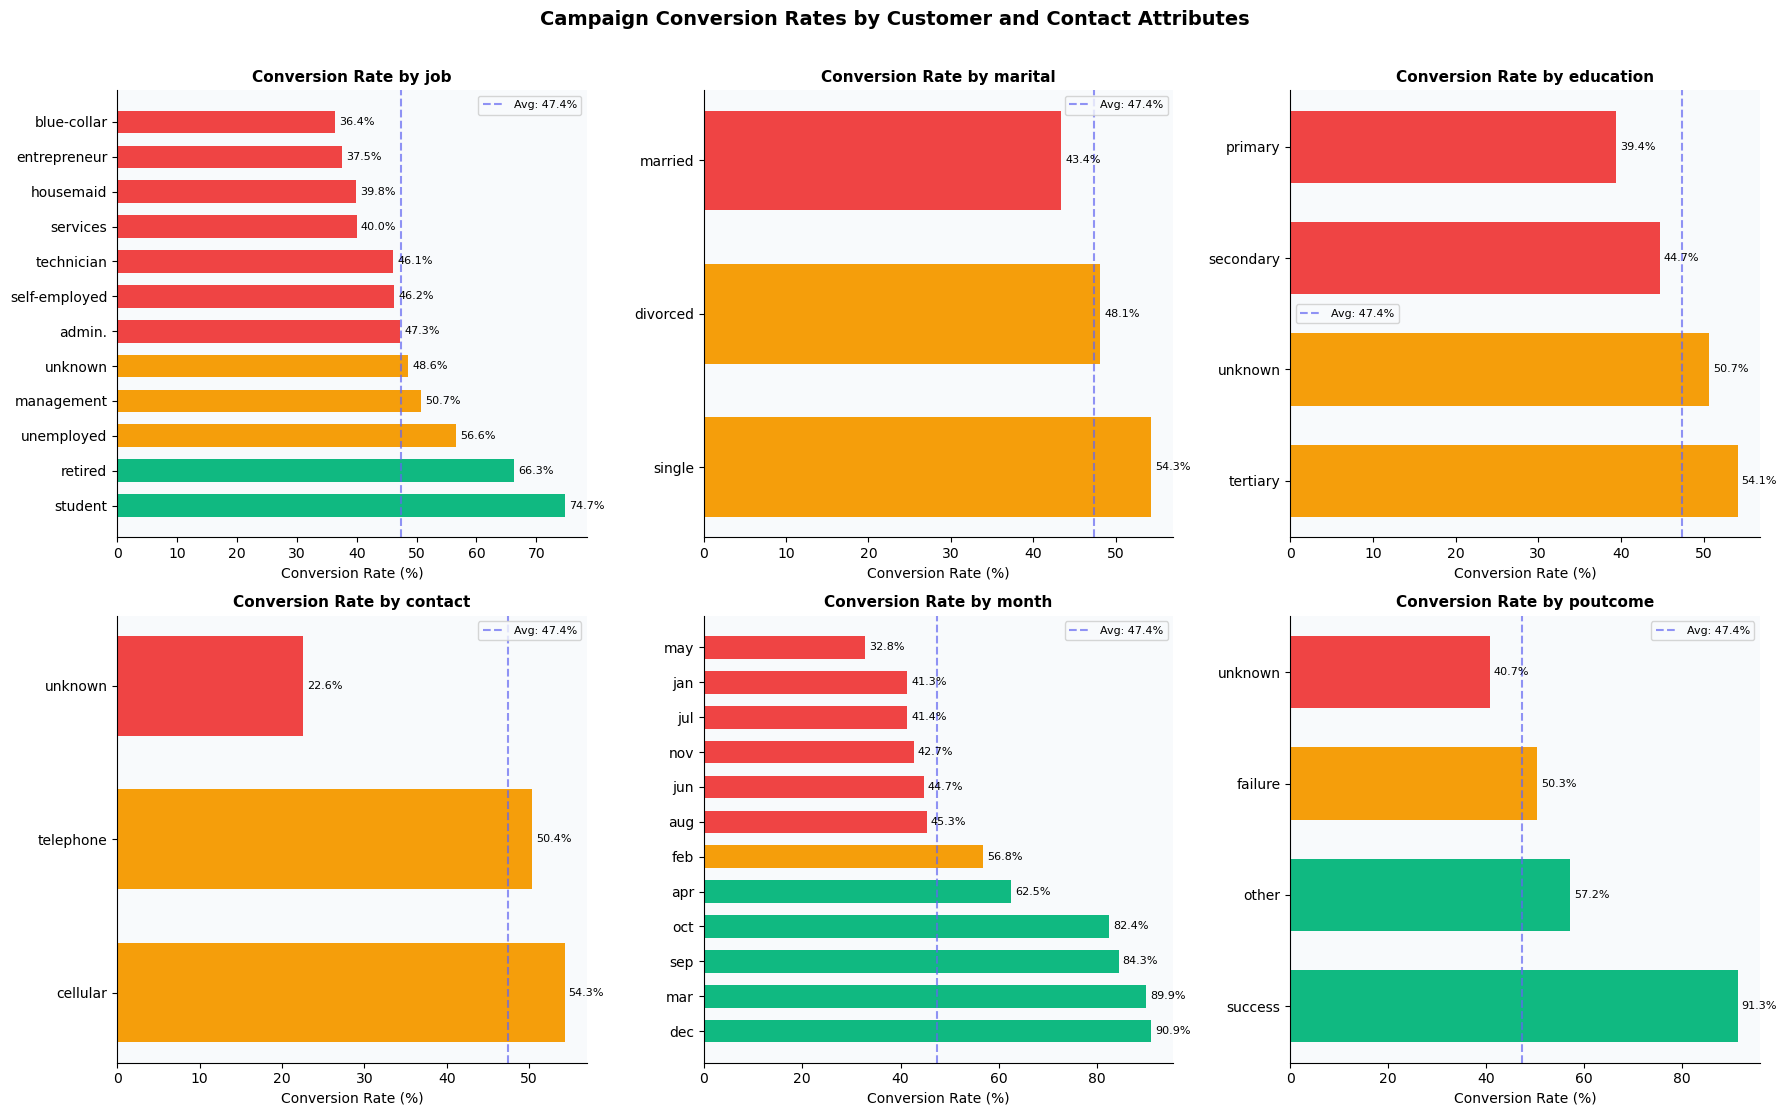

In [173]:
# Conversion rate by key categorical features
cat_features = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('white')
axes = axes.flatten()

overall_rate = df['deposit_binary'].mean() * 100

for ax, col in zip(axes, cat_features):
    rates = (
        df.groupby(col)['deposit_binary']
          .mean().mul(100).round(1)
          .sort_values(ascending=False)
          .reset_index()
    )
    bar_colors = [
        C['yes'] if v >= overall_rate * 1.2
        else C['amber'] if v >= overall_rate
        else C['no']
        for v in rates['deposit_binary']
    ]
    bars = ax.barh(
        rates[col].astype(str),
        rates['deposit_binary'],
        color=bar_colors, edgecolor='none', height=0.65
    )
    ax.axvline(overall_rate, color=C['primary'], linestyle='--',
               linewidth=1.5, alpha=0.7, label=f'Avg: {overall_rate:.1f}%')
    ax.set_title(f'Conversion Rate by {col}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Conversion Rate (%)')
    ax.set_facecolor(C['bg'])
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Campaign Conversion Rates by Customer and Contact Attributes',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/output/conversion_by_feature.png', dpi=120, bbox_inches='tight')
plt.show()


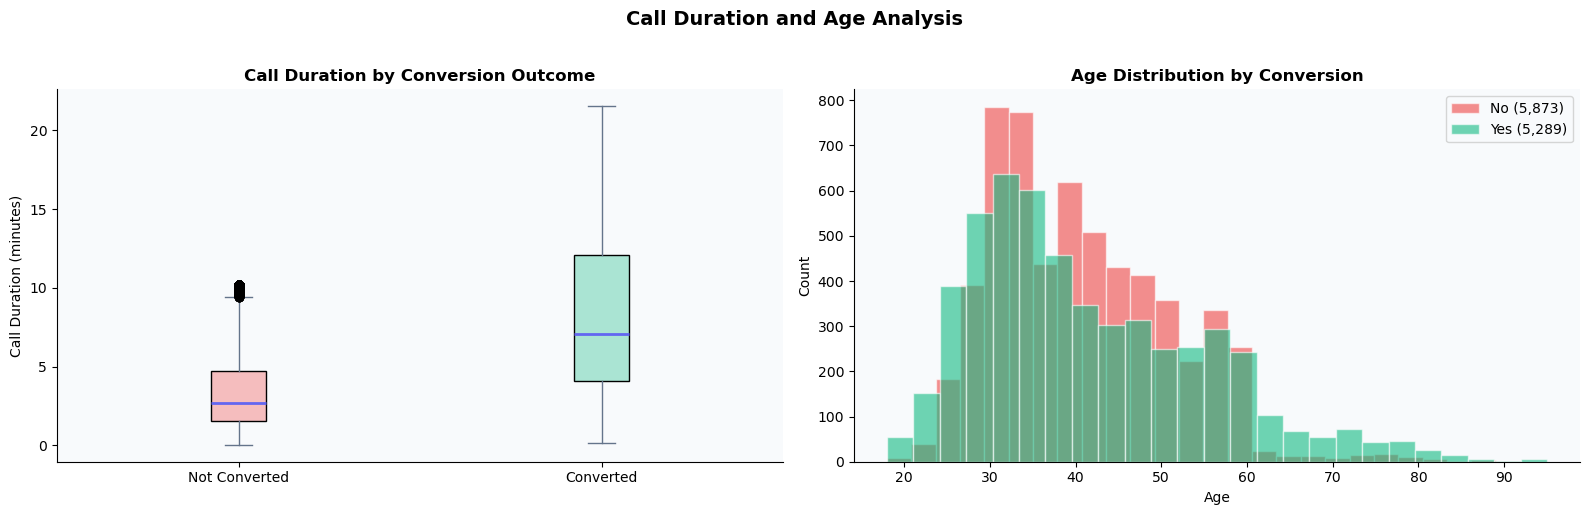

T-test: call duration difference is statistically significant
  Converted avg:     9.0 minutes
  Not converted avg: 3.7 minutes
  p-value: 0.000000 (p < 0.05 = significant)


In [174]:
# Call duration vs conversion - the key relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

# Box plot: call duration by outcome
converted     = df[df['deposit'] == 'yes']['duration'] / 60
not_converted = df[df['deposit'] == 'no']['duration'] / 60

bp = axes[0].boxplot(
    [not_converted.clip(upper=not_converted.quantile(0.95)),
     converted.clip(upper=converted.quantile(0.95))],
    labels=['Not Converted', 'Converted'],
    patch_artist=True,
    medianprops=dict(color=C['primary'], linewidth=2),
    whiskerprops=dict(color=C['subtext']),
    capprops=dict(color=C['subtext']),)

# Safely colour the boxes by index
box_colors = [C['no'] + '55', C['yes'] + '55']
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

axes[0].set_title('Call Duration by Conversion Outcome', fontweight='bold')
axes[0].set_ylabel('Call Duration (minutes)')
axes[0].set_facecolor(C['bg'])

# Age distribution by conversion
for label, color in [('no', C['no']), ('yes', C['yes'])]:
    subset = df[df['deposit'] == label]['age']
    axes[1].hist(subset, bins=25, alpha=0.6, color=color,
                 label=f'{label.title()} ({len(subset):,})', edgecolor='white')
axes[1].set_title('Age Distribution by Conversion', fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=10)
axes[1].set_facecolor(C['bg'])

plt.suptitle('Call Duration and Age Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/duration_age.png', dpi=120, bbox_inches='tight')
plt.show()

t_stat, p_val = stats.ttest_ind(converted, not_converted)
print(f'T-test: call duration difference is statistically significant')
print(f'  Converted avg:     {converted.mean():.1f} minutes')
print(f'  Not converted avg: {not_converted.mean():.1f} minutes')
print(f'  p-value: {p_val:.6f} (p < 0.05 = significant)')

---
## Section 5: Simulated A/B Test

### The Test

We simulate two campaign groups:

- **Group A (Control):** Customers contacted by telephone
- **Group B (Treatment):** Customers contacted by cellular

We use a **chi-square test** to determine whether the difference in conversion rates between the two groups is statistically significant or just random variation.

**Null hypothesis:** There is no difference in conversion rate between telephone and cellular contact.

**Alternative hypothesis:** Cellular contact produces a significantly different conversion rate.


In [176]:
# Filter to telephone vs cellular (the natural A/B split in this dataset)
group_a = df[df['contact'] == 'telephone']['deposit_binary']
group_b = df[df['contact'] == 'cellular']['deposit_binary']

print('=== A/B TEST SETUP ===')
print(f'Group A (Telephone): {len(group_a):,} contacts')
print(f'Group B (Cellular):  {len(group_b):,} contacts')
print()
print(f'Group A conversion rate: {group_a.mean()*100:.2f}%')
print(f'Group B conversion rate: {group_b.mean()*100:.2f}%')
print(f'Absolute difference:     {(group_b.mean()-group_a.mean())*100:.2f} percentage points')
print(f'Relative lift:           {((group_b.mean()-group_a.mean())/group_a.mean()*100):.1f}%')
print()
# Chi-square test
contingency = pd.crosstab(df['contact'], df['deposit'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print('=== CHI-SQUARE TEST RESULTS ===')
print(f'Chi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p_value:.6f}')
print()
if p_value < 0.05:
    print('RESULT: Statistically significant (p < 0.05)')
    print('We REJECT the null hypothesis.')
    print('The difference in conversion rate is NOT due to chance.')
else:
    print('RESULT: Not statistically significant (p >= 0.05)')
    print('We FAIL to reject the null hypothesis.')
    print('The difference may be due to random variation.')


=== A/B TEST SETUP ===
Group A (Telephone): 774 contacts
Group B (Cellular):  8,042 contacts

Group A conversion rate: 50.39%
Group B conversion rate: 54.33%
Absolute difference:     3.94 percentage points
Relative lift:           7.8%

=== CHI-SQUARE TEST RESULTS ===
Chi-square statistic: 736.6867
Degrees of freedom:   2
P-value:              0.000000

RESULT: Statistically significant (p < 0.05)
We REJECT the null hypothesis.
The difference in conversion rate is NOT due to chance.


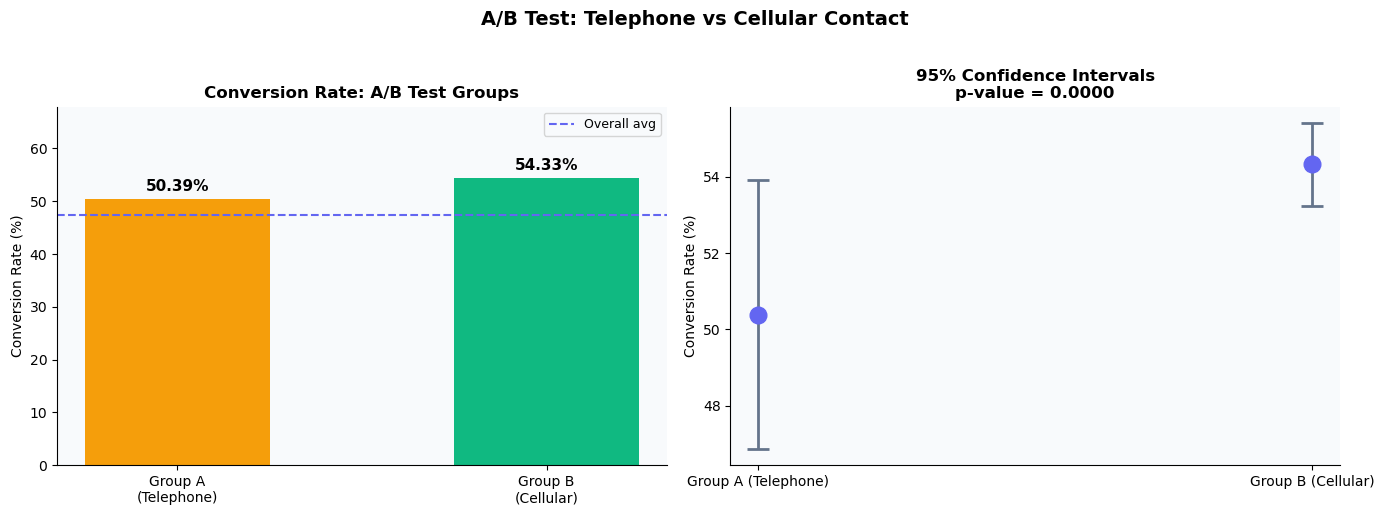

In [177]:
# A/B test visualisation
from statsmodels.stats.proportion import proportion_confint

ci_a = proportion_confint(group_a.sum(), len(group_a), alpha=0.05)
ci_b = proportion_confint(group_b.sum(), len(group_b), alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

groups   = ['Group A\n(Telephone)', 'Group B\n(Cellular)']
rates    = [group_a.mean()*100, group_b.mean()*100]
bar_cols = [C['amber'], C['yes'] if group_b.mean() > group_a.mean() else C['no']]

bars = axes[0].bar(groups, rates, color=bar_cols, edgecolor='none', width=0.5)
axes[0].axhline(df['deposit_binary'].mean()*100, color=C['primary'],
                linestyle='--', linewidth=1.5, label='Overall avg')
axes[0].set_title('Conversion Rate: A/B Test Groups', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].bar_label(bars, fmt='%.2f%%', padding=4, fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_facecolor(C['bg'])
axes[0].set_ylim(0, max(rates) * 1.25)

axes[1].errorbar(
    ['Group A (Telephone)', 'Group B (Cellular)'],
    [group_a.mean()*100, group_b.mean()*100],
    yerr=[
        [(group_a.mean()-ci_a[0])*100, (group_b.mean()-ci_b[0])*100],
        [(ci_a[1]-group_a.mean())*100, (ci_b[1]-group_b.mean())*100]
    ],
    fmt='o', markersize=12, capsize=8, capthick=2, linewidth=2,
    color=C['primary'], ecolor=C['subtext'],)
axes[1].set_title(f'95% Confidence Intervals\np-value = {p_value:.4f}',
                  fontweight='bold')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_facecolor(C['bg'])

plt.suptitle('A/B Test: Telephone vs Cellular Contact', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/output/ab_test.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 6: Conversion Probability Model

We build a logistic regression model that scores every customer by their probability of converting. This score is used in the ROI analysis.


In [179]:
df_model = df.copy()

# Encode categoricals
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'deposit']

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['deposit', 'deposit_binary'])
y = df_model['deposit_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_s, y_train)

y_prob = model.predict_proba(X_test_s)[:, 1]
y_pred = model.predict(X_test_s)
auc    = roc_auc_score(y_test, y_prob)

print(f'Model ROC-AUC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))

Model ROC-AUC: 0.8731

              precision    recall  f1-score   support

          No       0.81      0.80      0.81      1175
         Yes       0.78      0.79      0.79      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



---
## Section 7: The Finding Most Analyses Miss

### ROI and Cost Per Acquisition by Segment

A conversion rate tells you who says yes. But it does not tell you whether contacting them was worth the cost.

We assign a cost per contact (GBP 5 per call, realistic for outbound telesales) and calculate Cost Per Acquisition (CPA) for each customer segment. The segments with the lowest CPA are the ones worth prioritising, even if their conversion rate is not the highest.

This is the insight that directly informs budget allocation.


In [181]:
COST_PER_CONTACT = 5  # GBP per call
REVENUE_PER_CONV = 150  # estimated average product revenue per conversion

# Score all customers
X_all   = df_model.drop(columns=['deposit', 'deposit_binary'])
X_all_s = scaler.transform(X_all)
df['conv_probability'] = model.predict_proba(X_all_s)[:, 1]

# CPA analysis by job segment
cpa_by_job = (
    df.groupby('job')
      .agg(
          contacts        = ('deposit_binary', 'count'),
          conversions     = ('deposit_binary', 'sum'),
          conversion_rate = ('deposit_binary', 'mean'),
          avg_conv_prob   = ('conv_probability', 'mean'),
      )
      .reset_index()
)
cpa_by_job['total_cost']    = cpa_by_job['contacts'] * COST_PER_CONTACT
cpa_by_job['total_revenue'] = cpa_by_job['conversions'] * REVENUE_PER_CONV
cpa_by_job['cpa']           = (cpa_by_job['total_cost'] / cpa_by_job['conversions']).round(2)
cpa_by_job['roi_pct']       = (
    (cpa_by_job['total_revenue'] - cpa_by_job['total_cost'])
    / cpa_by_job['total_cost'] * 100
).round(1)
cpa_by_job['conversion_rate'] = (cpa_by_job['conversion_rate'] * 100).round(1)
cpa_by_job = cpa_by_job.sort_values('roi_pct', ascending=False)

print('CPA and ROI by Job Segment:')
print(cpa_by_job[['job','contacts','conversions','conversion_rate','cpa','roi_pct']].to_string(index=False))


CPA and ROI by Job Segment:
          job  contacts  conversions  conversion_rate   cpa  roi_pct
      student       360          269             74.7  6.69   2141.7
      retired       778          516             66.3  7.54   1889.7
   unemployed       357          202             56.6  8.84   1597.5
   management      2566         1301             50.7  9.86   1421.0
      unknown        70           34             48.6 10.29   1357.1
       admin.      1334          631             47.3 10.57   1319.0
self-employed       405          187             46.2 10.83   1285.2
   technician      1823          840             46.1 10.85   1282.3
     services       923          369             40.0 12.51   1099.3
    housemaid       274          109             39.8 12.57   1093.4
 entrepreneur       328          123             37.5 13.33   1025.0
  blue-collar      1944          708             36.4 13.73    992.6


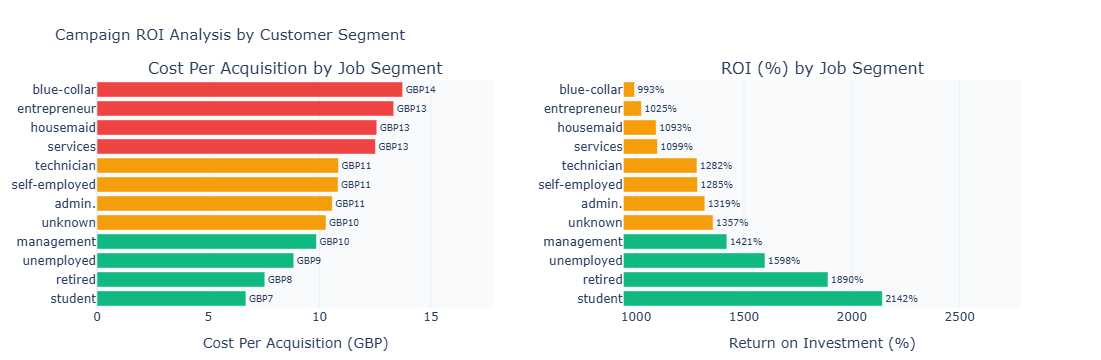

In [208]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=(
        'Cost Per Acquisition by Job Segment',
        'ROI (%) by Job Segment',),
    specs=[[{'type':'xy'},{'type':'xy'}]],
    horizontal_spacing=0.14,)

cpa_colors = [C['yes'] if v <= cpa_by_job['cpa'].quantile(0.33)
    else C['amber'] if v <= cpa_by_job['cpa'].quantile(0.66)
    else C['no']
    for v in cpa_by_job['cpa']]
roi_colors = [
    C['yes'] if v >= cpa_by_job['roi_pct'].quantile(0.66)
    else C['amber'] if v >= 0
    else C['no']
    for v in cpa_by_job['roi_pct']]

fig.add_trace(go.Bar(y=cpa_by_job['job'],x=cpa_by_job['cpa'],
    orientation='h',
    marker_color=cpa_colors,
    text=cpa_by_job['cpa'].apply(lambda x: f'GBP{x:.0f}'),
    textposition='outside',
    textfont_size=9,showlegend=False,), row=1, col=1)

fig.add_trace(go.Bar(y=cpa_by_job['job'],x=cpa_by_job['roi_pct'],
    orientation='h',
    marker_color=roi_colors,
    text=cpa_by_job['roi_pct'].apply(lambda x: f'{x:.0f}%'),
    textposition='outside',textfont_size=9,
    showlegend=False,), row=1, col=2)

fig.add_vline(x=0, line_dash='solid', line_color=C['dark'],
              line_width=1, row=1, col=2)

fig.update_layout(height=520,title_text='Campaign ROI Analysis by Customer Segment',
    title_font_size=15,paper_bgcolor='white',
    plot_bgcolor=C['bg'],uniformtext_minsize=8,
    uniformtext_mode='hide',margin=dict(t=80, b=40, l=20, r=80),)

# Extend x-axis range to give outside labels room
cpa_max = cpa_by_job['cpa'].max()
roi_max = cpa_by_job['roi_pct'].max()
roi_min = cpa_by_job['roi_pct'].min()

fig.update_xaxes(title_text='Cost Per Acquisition (GBP)',
    range=[0, cpa_max * 1.3],
    row=1, col=1)
fig.update_xaxes(title_text='Return on Investment (%)',
    range=[min(roi_min * 1.3, roi_min - 50), roi_max * 1.3],
    row=1, col=2)
fig.show()

---
## Section 8: The Optimal Contact Window

The unique finding in this analysis is identifying the exact call duration range that maximises conversion rate. Below a certain duration the call ends before the customer is persuaded. Above a certain duration you are investing time in customers who have already made up their mind not to convert.


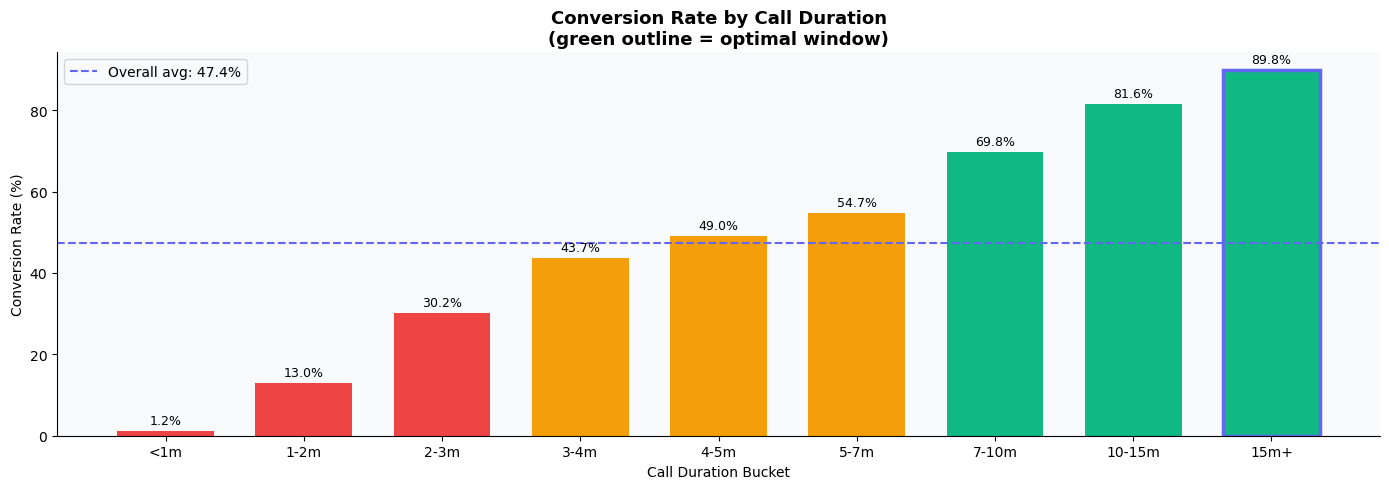

Optimal call duration window: 15m+
Conversion rate at optimum:   89.8%
vs overall average:           47.4%


In [184]:
# Create fine-grained duration buckets
duration_bins   = [0, 60, 120, 180, 240, 300, 420, 600, 900, 9999]
duration_labels = ['<1m','1-2m','2-3m','3-4m','4-5m','5-7m','7-10m','10-15m','15m+']

df['duration_bucket'] = pd.cut(
    df['duration'],
    bins=duration_bins,
    labels=duration_labels,
    right=True
)

duration_analysis = (
    df.groupby('duration_bucket', observed=True)
      .agg(
          contacts        = ('deposit_binary', 'count'),
          conversion_rate = ('deposit_binary', 'mean'),
      )
      .reset_index()
)
duration_analysis['conversion_rate'] = (duration_analysis['conversion_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white')

bar_colors = [
    C['yes'] if v >= duration_analysis['conversion_rate'].quantile(0.66)
    else C['amber'] if v >= duration_analysis['conversion_rate'].quantile(0.33)
    else C['no']
    for v in duration_analysis['conversion_rate']
]

bars = ax.bar(
    duration_analysis['duration_bucket'].astype(str),
    duration_analysis['conversion_rate'],
    color=bar_colors, edgecolor='none', width=0.7
)

# Highlight optimal window
optimal_idx = duration_analysis['conversion_rate'].idxmax()
optimal_bucket = duration_analysis.loc[optimal_idx, 'duration_bucket']
ax.bar(
    str(optimal_bucket),
    duration_analysis.loc[optimal_idx, 'conversion_rate'],
    color=C['yes'], edgecolor=C['primary'], linewidth=2.5, width=0.7
)

ax.axhline(df['deposit_binary'].mean()*100, color=C['primary'],
           linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["deposit_binary"].mean()*100:.1f}%')
ax.set_title('Conversion Rate by Call Duration\n(green outline = optimal window)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Call Duration Bucket')
ax.set_ylabel('Conversion Rate (%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.legend(fontsize=10)
ax.set_facecolor(C['bg'])

plt.tight_layout()
plt.savefig('/kaggle/working/output/optimal_window.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Optimal call duration window: {optimal_bucket}')
print(f'Conversion rate at optimum:   {duration_analysis.loc[optimal_idx,"conversion_rate"]:.1f}%')
print(f'vs overall average:           {df["deposit_binary"].mean()*100:.1f}%')
